## Hidden Markov Chain : Practice & Experiments

**Authored by Alexandre Mathias DONNAT, Sr - Télécom Paris**

This notebook explores the use of discrete-time Markov chains for modeling sequential data, with a specific application to language.

The core idea is simple: instead of modeling full words or sentences, we model local dependencies between consecutive characters using a transition matrix learned from real data (bigrams). From this structure, we can both:

generate synthetic sequences that resemble natural language,
and evaluate how likely a given sentence is under a specific model.

The workflow follows three main steps:

Word generation
A Markov chain is used to simulate sequences of characters starting from an initial state and stopping at a terminal state, producing synthetic words.
Sentence generation
The model is extended by introducing additional states to represent word boundaries and sentence termination, enabling the generation of full sentences.
Language recognition via likelihood
Given a sentence, its likelihood is computed under different models (e.g., English vs French), allowing for simple probabilistic classification.

In [ ]:
import numpy as np 

filename_A='bigramenglish.txt'
A=np.loadtxt(filename_A)
print(len(A))
filename_F='bigramfrancais.txt'
F=np.loadtxt(filename_F)
print(len(F))
dic={'1' : ' ', '2' : 'a', '3' : 'b', '4': 'c', '5' : 'd', '6' : 'e', '7': 'f', '8' : 'g', '9' : 'h', '10': 'i', '11': 'j',
'12' : 'k', '13' : 'l', '14': 'm', '15' : 'n', '16' : 'o', '17': 'p', '18' : 'q', '19' : 'r' , '20': 's', '21' : 't', '22'
: 'u', '23': 'v', '24' : 'w', '25' : 'x' , '26': 'y', '27' : 'z', '28' : ' '}
print(len(dic))

28
28
28


## I.2.a 
bigramenglish.txt' contient la matrice des transitions pour l’anglais (bigrams) entre deux symboles (caractères ou espaces). Le terme générique (i,j) de la matrice de transition correspond à la probabilité de transiter vers l’état j à partir de l’état i.
A quelles probabilités correspond la première ligne de la matrice de transition ? et celles de la dernière colonne ?
Pour chaque lettre de l’alphabet, indiquer la transition la plus fréquente depuis cette lettre

In [3]:
# I.2.a

# Réponse théorique :
# - La première ligne de la matrice correspond aux probabilités de transition
#   depuis l'état initial 1, c'est-à-dire depuis l'espace de début de mot,
#   vers chacun des états possibles (a, b, ..., z, ou espace final).
#   Autrement dit, elle donne la distribution de la première lettre d’un mot.
#
# - La dernière colonne correspond aux probabilités de transition vers l'état 28,
#   c'est-à-dire vers l'espace de fin de mot, depuis chacun des états de départ.
#   Autrement dit, elle indique pour chaque lettre la probabilité que le mot
#   s’arrête juste après cette lettre.

print("Taille de la matrice anglaise :", A.shape)

# Pour chaque lettre (états 2 à 27), on cherche l'état le plus probable à t+1
print("Transition la plus fréquente depuis chaque lettre :\n")

for i in range(1, 27):   # indices Python 1..26 <=> états 2..27
    j_max = np.argmax(A[i])          # indice Python du max
    etat_depart = str(i + 1)         # état réel
    etat_arrivee = str(j_max + 1)    # état réel
    
    print(f"Depuis '{dic[etat_depart]}' -> '{dic[etat_arrivee]}' "
          f"(proba = {A[i, j_max]:.4f})")

Taille de la matrice anglaise : (28, 28)
Transition la plus fréquente depuis chaque lettre :

Depuis 'a' -> 'n' (proba = 0.2205)
Depuis 'b' -> 'e' (proba = 0.2828)
Depuis 'c' -> 'o' (proba = 0.1669)
Depuis 'd' -> ' ' (proba = 0.5988)
Depuis 'e' -> ' ' (proba = 0.3605)
Depuis 'f' -> ' ' (proba = 0.3965)
Depuis 'g' -> ' ' (proba = 0.3157)
Depuis 'h' -> 'e' (proba = 0.4697)
Depuis 'i' -> 'n' (proba = 0.2453)
Depuis 'j' -> 'o' (proba = 0.4698)
Depuis 'k' -> ' ' (proba = 0.3723)
Depuis 'l' -> 'e' (proba = 0.1709)
Depuis 'm' -> 'e' (proba = 0.2677)
Depuis 'n' -> ' ' (proba = 0.2942)
Depuis 'o' -> 'n' (proba = 0.1604)
Depuis 'p' -> 'e' (proba = 0.1947)
Depuis 'q' -> 'u' (proba = 0.9637)
Depuis 'r' -> 'e' (proba = 0.2448)
Depuis 's' -> ' ' (proba = 0.4303)
Depuis 't' -> 'h' (proba = 0.3394)
Depuis 'u' -> 'r' (proba = 0.1504)
Depuis 'v' -> 'e' (proba = 0.6184)
Depuis 'w' -> 'a' (proba = 0.2032)
Depuis 'x' -> 't' (proba = 0.2006)
Depuis 'y' -> ' ' (proba = 0.7758)
Depuis 'z' -> 'e' (proba = 0.55

## I.2.b


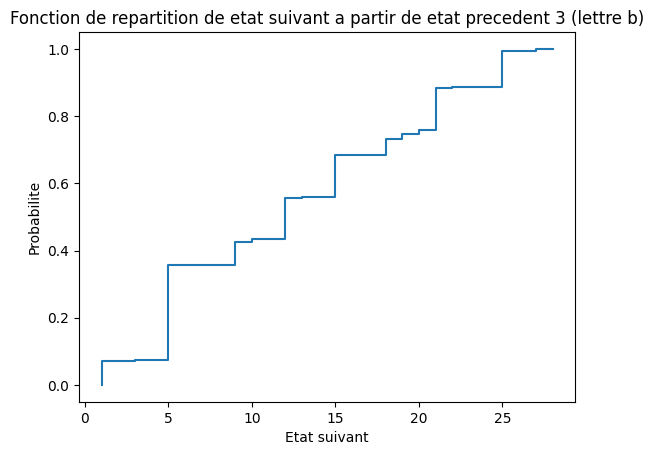

In [4]:
plt.step(range(1, 29), np.cumsum(A[2,]))
#plt.step()
plt.title('Fonction de repartition de etat suivant a partir de etat precedent 3 (lettre b)')
plt.xlabel('Etat suivant')
plt.ylabel('Probabilite') 
plt.show()

In [5]:
def etat_suivant(ligne_matrice_trans):
    '''
    La fonction génère un état (à t+1) à partir de l’état courant (à t) 
    La ligne de la matrice de transitions correspond aux probabilités 
    de transiter de l etat courant vers les autres etats.
    '''
    f_repartition = np.cumsum(ligne_matrice_trans)
    unif = np.random.random()
    stat = 0
    while(unif >= f_repartition[stat]):
        stat = stat+1
    return stat+1

In [6]:
def generate_state_seq(A):
    """
    Génère une séquence d'états à partir de l'état initial 1
    jusqu'à l'état final 28.
    """
    t = 1                 # on commence à l'état initial
    stateSeq = [t]        # on stocke aussi l'état initial

    while t != 28:        # tant qu'on n'a pas atteint l'état final
        t = etat_suivant(A[t-1])   # A[t-1] car Python indexe à partir de 0
        stateSeq.append(t)

    return stateSeq

In [42]:
def display_seq(seq, dic):
    str_seq = ""
    for s in seq:
        str_seq += dic[str(s)]
    return str_seq

In [44]:
seq = generate_state_seq(A)
print(display_seq(seq, dic))

 fe 


# I.2.c

On veut générer une suite de mots (phrase). Créer un état final de phrase (état 29, correspondant au caractère . ) dont la probabilité de transition vers cet état depuis un état final de mot est 0.1. Ecrire une fonction modifie_mat_dic qui modifie la matrice de transition et le dictionnaire en conséquence. Donner des exemples de phrases générées.

In [103]:
def modifie_mat_dic(A, dic):
    dic_mod = dic.copy()
    dic_mod['29'] = '.'

    A_mod = np.zeros((29, 29))

    # recopier la matrice originale
    A_mod[:28, :28] = A
    A_mod[27, :] = 0.0
    A_mod[27, 0] = 0.9    # + -> -
    A_mod[27, 28] = 0.1   # + -> .

    # état final de phrase absorbant
    A_mod[28, :] = 0.0
    A_mod[28, 28] = 1.0

    return A_mod, dic_mod

In [104]:
Amod,dicmod=modifie_mat_dic(A,dic)

In [105]:
def genere_phrase(A, dic):
    t = 1
    stateSeq = [t]   # on commence à l'état initial

    while t != 29:
        t = etat_suivant(A[t-1])
        stateSeq.append(t)

    return stateSeq

In [108]:
print('generation de phrases :')
for i in range(5):
    state_seq = genere_phrase(Amod, dicmod)
    print(display_seq(state_seq, dicmod))

generation de phrases :
 thememernt  aden  vo  th  custher  s  muse  ted  d  tich  cout  ldinak  f  ln  wid  m  wof  od  t  ntid .
 susnge  tofofe  gh  n  n  on  anoman  wisclit  be  t .
 can  s  le  husce  tirkif  n  g  g  s  ho  hef  thind  ometharss  thomf  es  ofaunilue  teny  n  rowhathisivarather  sangaf  bysthe  t  iseequt  ar  osa  ssure  a  ackighe  thee  themeis  f  tce  il  this  oks  nle  an  br  ree  ber  tas  y  alobilicithe  s  s  w  he  are .
 iccaste  iated .
 innsthiree .


## I.3


In [109]:
#transformer les espaces en +/- dans le dictionnaire et inversion
dicmod['1']='-'
dicmod['28']='+'
dicmod['29']='.'

Charger la matrice des transitions entre caractères pour le français. Ecrire une fonction calc_vraisemblance qui calcule la vraisemblance du modèle français pour une phrase donnée en multipliant les probabilités de transition. Pour tenir compte de toutes les transitions (notamment celles entre espaces de fin et de début de mots et vers la fin de phrase) on pourra transformer une séquence « mot1 mot2.» par la séquence « -mot1+-mot2+.», les signes - , + et . représentant l’état initial de mot, l’état final de mot et l’état final de phrase, respectivement.


In [110]:
def calc_vraisemblance(string, dic, mat):
    dicInv = {v: k for k, v in dic.items()}
    
    vraisemblance = 1.0
    
    # état initial correspondant au premier caractère
    state = int(dicInv[string[0]])
    
    for c in string[1:]:
        next_state = int(dicInv[c])
        vraisemblance *= mat[state-1, next_state-1]
        state = next_state
        
    return vraisemblance

In [111]:
def calc_log_vraisemblance(string, dic, mat):
    dicInv = {v: k for k, v in dic.items()}
    
    log_vraisemblance = 0.0
    state = int(dicInv[string[0]])
    
    for c in string[1:]:
        next_state = int(dicInv[c])
        p = mat[state-1, next_state-1]
        
        if p == 0:
            return -np.inf   # transition impossible
        
        log_vraisemblance += np.log(p)
        state = next_state
        
    return log_vraisemblance

Calculer la vraisemblance des modèles français et anglais pour la phrase « to be or not to be ». De même calculer la vraisemblance des modèles français et anglais pour la phrase « etre ou ne pas etre ».

In [ ]:
# 1. Préparation modèles

Amod, dicmod_a = modifie_mat_dic(A, dic.copy())
dicmod_a['1'] = '-'
dicmod_a['28'] = '+'
dicmod_a['29'] = '.'

Fmod, dicmod_f = modifie_mat_dic(F, dic.copy())
dicmod_f['1'] = '-'
dicmod_f['28'] = '+'
dicmod_f['29'] = '.'

# 2. Phrases test

sentence1 = "-to+-be+-or+-not+-to+-be+."
sentence2 = "-etre+-ou+-ne+-pas+-etre+."

# 3. Calcul log-vraisemblances

lv1_en = calc_log_vraisemblance(sentence1, dicmod_a, Amod)
lv1_fr = calc_log_vraisemblance(sentence1, dicmod_f, Fmod)

lv2_en = calc_log_vraisemblance(sentence2, dicmod_a, Amod)
lv2_fr = calc_log_vraisemblance(sentence2, dicmod_f, Fmod)

# 4. Affichage résultats

print("Phrase 1 :", sentence1)
print("Log-vraisemblance modèle anglais :", lv1_en)
print("Log-vraisemblance modèle français :", lv1_fr)
print("=> Modèle le plus vraisemblable :", "anglais" if lv1_en > lv1_fr else "français")

print()

print("Phrase 2 :", sentence2)
print("Log-vraisemblance modèle anglais :", lv2_en)
print("Log-vraisemblance modèle français :", lv2_fr)
print("=> Modèle le plus vraisemblable :", "anglais" if lv2_en > lv2_fr else "français")

Phrase 1 : -to+-be+-or+-not+-to+-be+.
Log-vraisemblance modèle anglais : -43.958247430445105
Log-vraisemblance modèle français : -67.29244739293277
=> Modèle le plus vraisemblable : anglais

Phrase 2 : -etre+-ou+-ne+-pas+-etre+.
Log-vraisemblance modèle anglais : -53.766380433373605
Log-vraisemblance modèle français : -43.61309495161034
=> Modèle le plus vraisemblable : français
